In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [3]:
# Step 2: Load dataset
data = pd.read_csv("iris (2).csv")

In [4]:
# Step 3: Select features (drop non-numeric columns if any)
X = data.select_dtypes(include=['float64', 'int64'])

In [5]:
k = 3   # number of clusters
kmeans = KMeans(n_clusters=k, random_state=0)
kmeans.fit(X)

KMeans(n_clusters=3, random_state=0)

In [6]:
labels = kmeans.labels_


In [7]:
# Step 6: Add labels to dataset
data['Cluster'] = labels

In [8]:

# Step 7: Print clustered data
print(data.head())

   sepal_length  sepal_width  petal_length  petal_width      species  Cluster
0           5.1          3.5           1.4          0.2  Iris-setosa        1
1           4.9          3.0           1.4          0.2  Iris-setosa        1
2           4.7          3.2           1.3          0.2  Iris-setosa        1
3           4.6          3.1           1.5          0.2  Iris-setosa        1
4           5.0          3.6           1.4          0.2  Iris-setosa        1


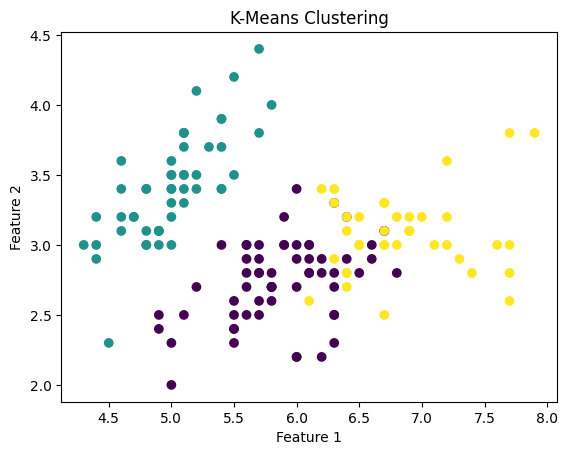

In [9]:
# Step 8: Visualization (using first two features)
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=labels)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means Clustering")
plt.show()

In [ ]:
# Step 1: Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

# Step 2: Load dataset
data = pd.read_csv("income.csv")

# Step 3: Handle categorical data
le = LabelEncoder()
for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = le.fit_transform(data[col])

# Step 4: Split features and target
X = data.drop("income", axis=1)   # target column assumed as 'income'
y = data["income"]

# Step 5: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Step 6: AdaBoost with n_estimators = 10
model = AdaBoostClassifier(n_estimators=10, random_state=42)
model.fit(X_train, y_train)

# Step 7: Prediction and accuracy
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy with 10 estimators:", accuracy)

In [ ]:
# Try different number of trees
best_score = 0
best_n = 0

for n in [10, 20, 50, 100, 200]:
    model = AdaBoostClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"n_estimators = {n}, Accuracy = {acc}")

    if acc > best_score:
        best_score = acc
        best_n = n

print("\nBest Accuracy:", best_score)
print("Best n_estimators:", best_n)